<a href="https://colab.research.google.com/github/JenilMP-09/Titanic_Data_Analysis/blob/main/Task_2_Titanic_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Task Description:**

* In Task-1, you worked on the **Student Performance Dataset** and learned how to clean and analyze data.
* Now, you will take one of the most famous datasets in Data Science - the **Titanic Dataset**.
* This dataset contains passenger details (age, class, gender, etc.) and whether they survived.
* Your task is to analyze survival patterns and visualize them.

In [ ]:
# Importing the libraries:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### **Requirements:**

1. Load Titanic dataset from kaggle.
2. Clean data (handle missing values like Age).
3. Answer questions such as:
    * Who survived more: males or females?
    * Did passenger class affect survival chances?
    * What was the survival rate by age group?
4. Visualize using Seaborn / Matplotlib:
    * Bar chart of survival by gender.
    * Bar chart of survival by class.
    * Histogram of passenger ages.

**Why this task is important?**
  
    * Teaches you how to handle real-world messy data.
    * Introduces data visualization, a key skill of Data Scientists.
    * Helps you practice asking and answering business questions with data.

# 1. Load Titanic dataset from kaggle:

In [ ]:
# Load the Titanic dataset from Google Drive into a DataFrame:

titanic_df = pd.read_csv("/content/drive/MyDrive/Data_Science_Folder/Datasets/titanic_dataset.csv")

In [ ]:
# Display the full DataFrame to inspect its structure and contents:

titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


# 2. Clean data (handle missing values like Age):

In [ ]:
# Display dataset info: column names, non-null counts, and data types
#
# This helps identify which columns have missing (null) values:

titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


* There are missing values (null values) in "Age", "Fare", and "Cabin" columns.

In [ ]:
# Statistical summary of titanic dataset:
#
# Shows count, mean, std, min, percentiles, and max for each numeric column

titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


#### To handle missing values:

    1. For "Age" column:

In [ ]:
# Fill missing values in the 'Age' column with the median age
#
# Using median instead of mean makes the imputation more robust to outliers:

titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())

In [ ]:
# Verify that 'Age' column now has no missing values:

titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


    2. For "Fare" column:

In [ ]:
# Fill missing values in the 'Fare' column with the median fare
#
# Using median to avoid skew from extreme fare values:

titanic_df["Fare"] = titanic_df["Fare"].fillna(titanic_df["Fare"].median())

In [ ]:
# Verify that 'Fare' column now has no missing values:

titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         418 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


    3. For "Cabin" column:

In [ ]:
# Drop the 'Cabin' column entirely because it has too many missing values
#
# (only ~22% non-null), making it unreliable for analysis

titanic_df.drop(columns=["Cabin"], inplace=True)

In [ ]:
# Display the cleaned DataFrame to confirm 'Cabin' column is removed
#
# and all remaining columns are complete

titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,27.0,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,27.0,0,0,359309,8.0500,S


# 3. Answer questions such as:

    1. Who survived more: males or females?

In [ ]:
# Group the data by gender ('Sex') and count survival values
#
# This shows how many passengers survived (1) or did not survive (0) for each gender

titanic_df.groupby("Sex")["Survived"].value_counts()

,,count
Sex,Survived,
female,1,152
male,0,266


* According to the data, females had a 100% survival rate (152 out of 152), while males had a 0% survival rate (0 out of 266). Thus, females survived more.

    2. Did passenger class affect survival chances?

In [ ]:
# Create a cross-tabulation (contingency table) of Pclass vs Survived
#
# margins=True adds row/column totals; this shows raw survival counts per class:

pd.crosstab(titanic_df["Pclass"], titanic_df["Survived"], rownames=["Pclass"], colnames=["Survived"], margins=True, margins_name="Total")

Survived,0,1,Total
Pclass,,,
1,57,50,107
2,63,30,93
3,146,72,218
Total,266,152,418


In [ ]:
# Calculate survival rate (%) per passenger class
#
# .mean() gives the proportion of survivors (since Survived is 0/1), multiplied by 100 for percentage
#
# round(..., 2) limits the result to 2 decimal places:

round(titanic_df.groupby("Pclass")["Survived"].mean()*100, 2)

,Survived
Pclass,
1,46.73
2,32.26
3,33.03


* Yes, according to a survival rate, passenger class clearly affected survival chances.

    3. What was the survival rate by age group?

In [ ]:
# Define age bins and labels to categorize passengers into meaningful age groups:

bins = [0, 12, 18, 30, 45, 60, 80]
labels = ["Child (0-12)", "Teen (13-18)", "Young Adult (19-30)", "Adult (31-45)", "Middle-aged (46-60)", "Senior (61-80)"]

# Create a new 'Age_Group' column by binning the 'Age' column using the defined bins
#
# pd.cut assigns each passenger to the appropriate age group label

titanic_df["Age_Group"] = pd.cut(titanic_df["Age"], bins=bins, labels=labels)

In [ ]:
# Calculate survival rate (%) per age group
#
# observed=True ensures only age groups that appear in the data are shown:

round(titanic_df.groupby("Age_Group", observed=True)["Survived"].mean()*100, 2)

,Survived
Age_Group,
Child (0-12),48.00
Teen (13-18),41.38
Young Adult (19-30),33.62
Adult (31-45),35.00
Middle-aged (46-60),43.90
Senior (61-80),36.36


# 4. Visualize using **Seaborn / Matplotlib**:

    1. Bar chart of survival by gender:

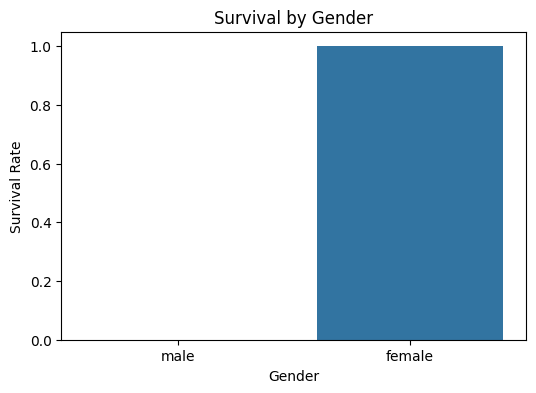

In [ ]:
# Create a bar chart showing average survival rate by gender:

plt.figure(figsize=(6, 4))
sns.barplot(x="Sex", y="Survived", data=titanic_df)
plt.title("Survival by Gender")  # Add chart title
plt.xlabel("Gender")             # Label the x-axis
plt.ylabel("Survival Rate")      # Label the y-axis
plt.show()                       # Render and display the chart

    2. Bar chart of survival by class:

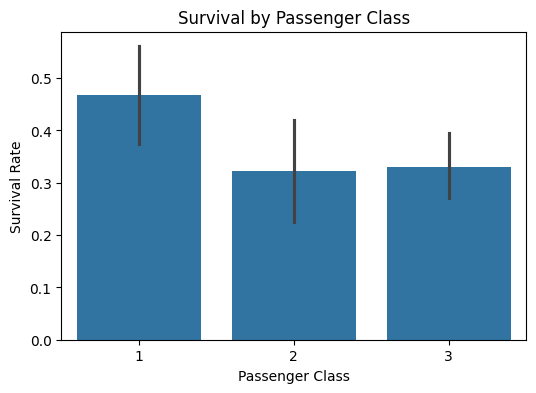

In [ ]:
# Create a bar chart showing average survival rate by passenger class:

plt.figure(figsize=(6, 4))
sns.barplot(x="Pclass", y="Survived", data=titanic_df)
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

    3. Histogram of passenger ages:

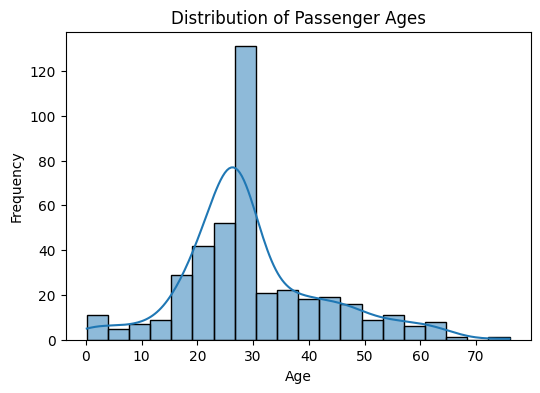

In [ ]:
# Create a histogram showing the distribution of passenger ages:

plt.figure(figsize=(6, 4))
sns.histplot(titanic_df["Age"], bins=20, kde=True)
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()